In [2]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [10]:
df=pd.read_csv("E:\\DataScience-project\\notebook\\data\\StudentsPerformance.csv")

In [11]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Shape of the dataset

In [12]:
df.shape

(1000, 8)

# Dataset information
- gender: sex of student ->(Male/female)
- race/ethnicity : ethnicity of students ->(Group A,B,C,D,E)
- parental level of education : parents' final education -> (bachlors' degreee ,some college,master's degree,high school)
- lunch: having lunch before test(standard or free/reduced)
- test preparation course : comlete or not complete before test
- math score 
- reading score 
-writing score 
# Data Checks to perform
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column 
- Check statistics of data set
- Check various categories in the different categorical column

# Check Missing values

In [15]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [18]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

# Check statisstics of data set

In [19]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Insight 
- From above description of numerical data ,all means are very close to each other - between 66 and 68.05;
- All standard devations are also close - between 14.6 and 15.19;
- while there is a minimum score 0 for math for writing  minimum is much higher =10 and for reaading might higher =17
# Exploring Data


In [21]:
print("Categories in 'gender' variables: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variables: ", end=" ")
print(df['race/ethnicity'].unique() )

print("Categories in 'parental level of education' variables: ", end=" ")
print(df['parental level of education'].unique() )

print("Categories in 'lunch' variables: ", end=" ")
print(df['lunch'].unique() )

print("Categories in 'test preparation course' variables: ", end=" ")
print(df['test preparation course'].unique() )

Categories in 'gender' variables:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variables:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variables:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variables:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variables:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [22]:
# define numerical & categorical columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
# print columns 
print("We have {} numerical features : {}".format(len(numerical_features), numerical_features))
print("We have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 8 numerical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
We have 0 categorical features : []


# Adding columns for "Total Score" and "Average"


In [23]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [25]:
reading_full=df[df['reading score'] == 100 ]['average score'].count()
writing_full=df[df['writing score'] == 100 ]['average score'].count()
math_full=df[df['math score'] == 100 ]['average score'].count() 

print("Number of students who got full marks in math : ", math_full)
print("Number of students who got full marks in reading : ", reading_full)
print("Number of students who got full marks in writing : ", writing_full)

Number of students who got full marks in math :  7
Number of students who got full marks in reading :  17
Number of students who got full marks in writing :  14


In [26]:
reading_less_20=df[df['reading score'] <= 20 ]['average score'].count()
writing_less_20=df[df['writing score'] <= 20 ]['average score'].count()
math_less_20=df[df['math score'] <= 20 ]['average score'].count()
print("Number of students who got less than 20 in reading : ", reading_less_20) 
print("Number of students who got less than 20 in writing : ", writing_less_20)
print("Number of students who got less than 20 in math : ", math_less_20)

Number of students who got less than 20 in reading :  1
Number of students who got less than 20 in writing :  3
Number of students who got less than 20 in math :  4


# insights
- From above values we get students have performed the worst in maths 
- Best performance is in reading section

# exploring data (visualization)

### VIsualize average score distribution to make some conclusion.
- Histogram
- Kernel Distribution FUnction(KDE)

# Histogram & KDEe

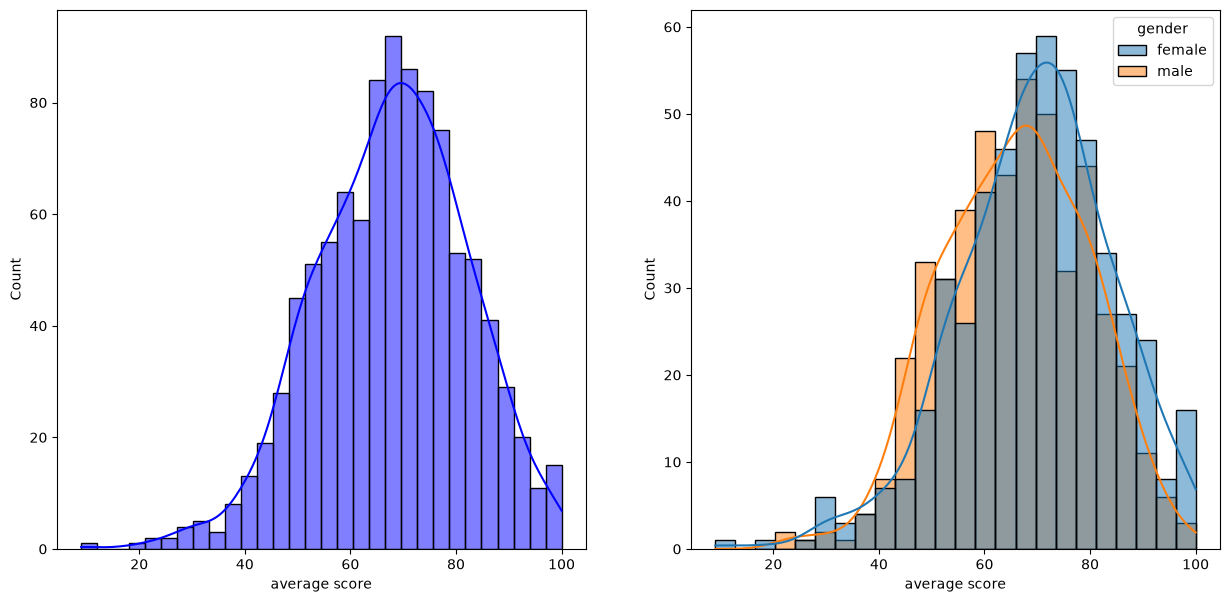

In [27]:
fig,axs =plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average score',bins=30,kde=True,color='blue')
plt.subplot(1,2,2)
sns.histplot(data=df,x='average score',kde=True,hue='gender')
plt.show()

## insigts
- female  student tend to perform well then male students

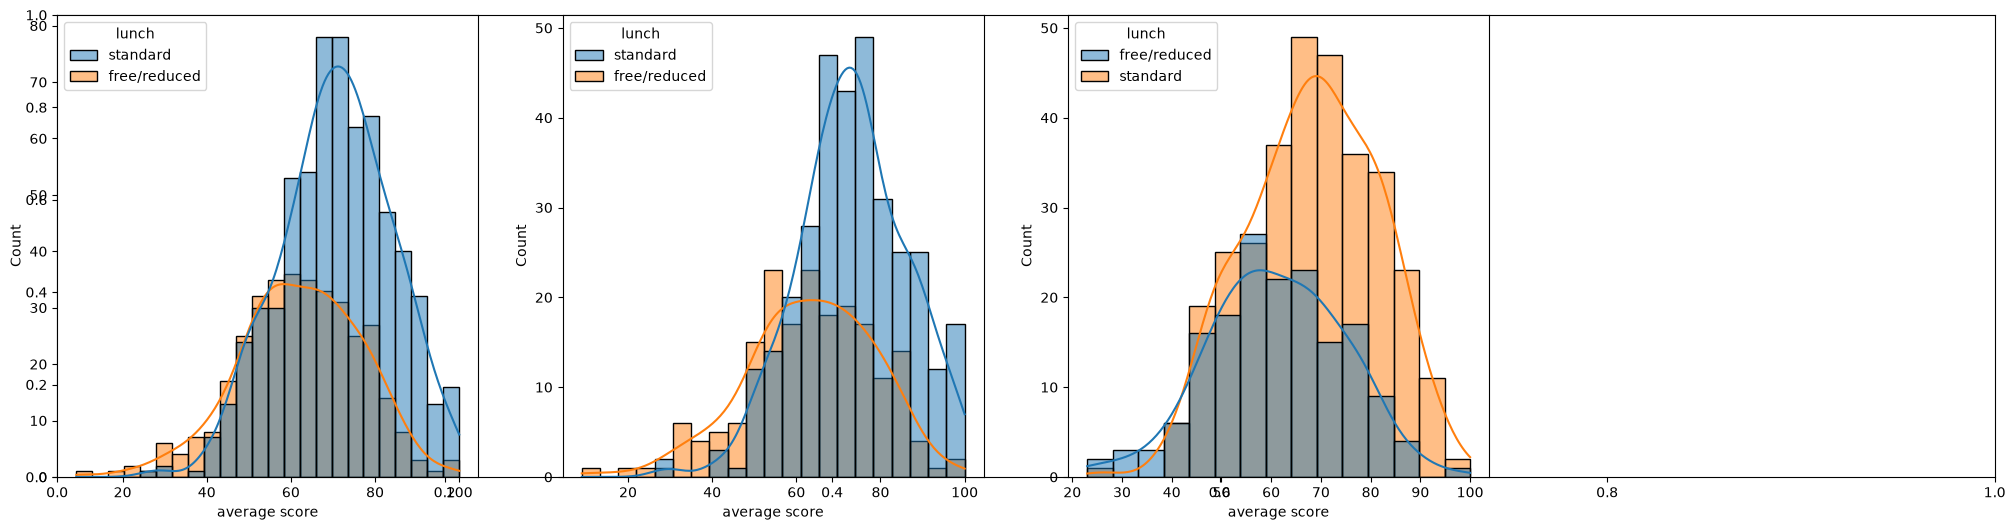

In [28]:
plt.subplots(figsize=(25,6))
plt.subplot(1,4,1)
sns.histplot(data=df,x='average score',kde=True,hue='lunch')
plt.subplot(1,4,2)  
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='lunch')
plt.subplot(1,4,3)
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='lunch')

plt.show()